# Customer Churn EDA

## Objective
To understand the dataset, analyze customer behavior, and identify factors affecting churn. This analysis will help in preparing the data for further preprocessing and model building.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [7]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Basic Info of the dataset

In [18]:
print("Total rows and columns:\n ",df.shape)

Total rows and columns:
  (7043, 21)


In [19]:
print("Column Names:\n", df.columns)

Column Names:
 Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Statistical Summary

In [28]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Statistical Summary Analysis

The summary shows that `SeniorCitizen` is a binary feature stored as numeric.  
`tenure` ranges from 0 to 72, where 0 may need further checking.  
`MonthlyCharges` appears to be within a reasonable range.

No clear issues are visible here, but further checks are needed.

In [34]:
print("Unique values in each columns: \n",df.nunique())

Unique values in each columns: 
 customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [37]:
print("Missing Values:\n",df.isnull().sum())

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [43]:
df.head().T.assign(Data_Type=df.dtypes)

,0,1,2,3,4,Data_Type
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU,str
gender,Female,Male,Male,Male,Female,str
SeniorCitizen,0,0,0,0,0,int64
Partner,Yes,No,No,No,No,str
Dependents,No,No,No,No,No,str
tenure,1,34,2,45,2,int64
PhoneService,No,Yes,Yes,No,Yes,str
MultipleLines,No phone service,No,No,No phone service,No,str
InternetService,DSL,DSL,DSL,DSL,Fiber optic,str
OnlineSecurity,No,Yes,Yes,Yes,No,str


### Data Type and Consistency Observations

From the data preview with data types, most columns appear consistent with their values.

- The `TotalCharges` column contains numerical values but is stored as an object type, which indicates a data type inconsistency. This column will need to be converted to a numeric format during data cleaning.

- Several columns such as `gender`, `Partner`, `Dependents`, and `Churn` are categorical and correctly stored as object type.

- The `SeniorCitizen` column is stored as an integer but represents a binary categorical feature (0 and 1). This may be treated as a categorical variable during preprocessing.

- No immediate issues are observed in `tenure` and `MonthlyCharges`, as their data types align with their values.

Overall, the main cleaning requirement identified at this stage is the conversion of `TotalCharges` to a numeric data type.

In [44]:
df.duplicated().sum()

np.int64(0)

No duplicate rows were found in the dataset, so no action is required for duplicate removal.

## Visual Analysis

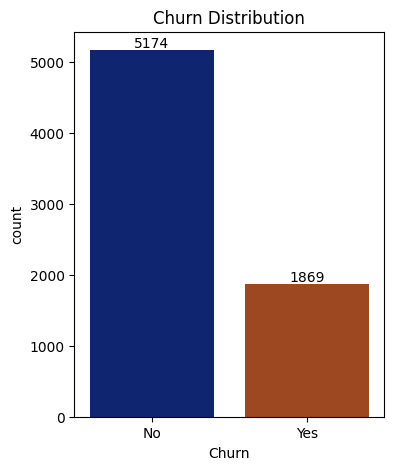

In [71]:
plt.figure(figsize=(4,5)) 
ax = sns.countplot(x='Churn', data=df, hue='Churn', palette='dark')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn Distribution')
plt.show()

#### Insight

From the visualization, most customers have not churned (5174), while a smaller portion has churned (1869).

This indicates that the dataset is imbalanced, with significantly more non-churn customers than churned ones. This imbalance should be kept in mind during further analysis and modeling.

## Churn by Contract Type

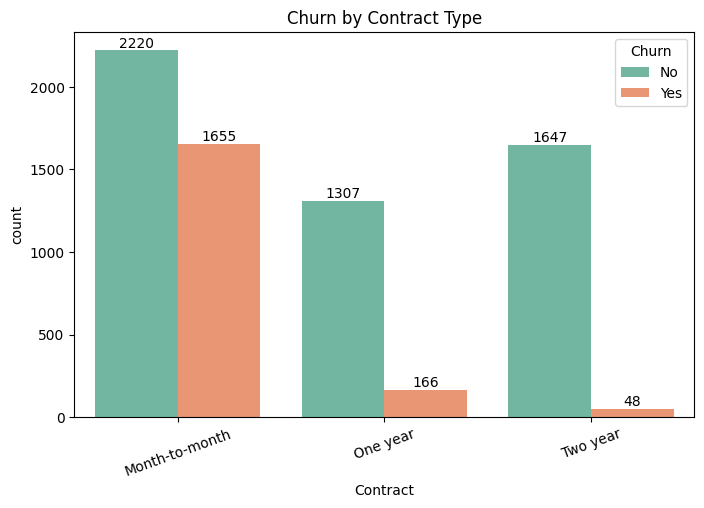

In [56]:
plt.figure(figsize=(8,5)) 
ax = sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn by Contract Type')
plt.xticks(rotation=20)
plt.show()

#### Insight

- From the visualization, customers with month-to-month contracts have the highest churn count compared to other contract types.
- Customers with one-year and two-year contracts show significantly lower churn, especially those on two-year contracts, where churn is minimal.
- This suggests that longer-term contracts are associated with better customer retention, while customers without long-term commitment are more likely to leave.

## Monthly Charges Distribution

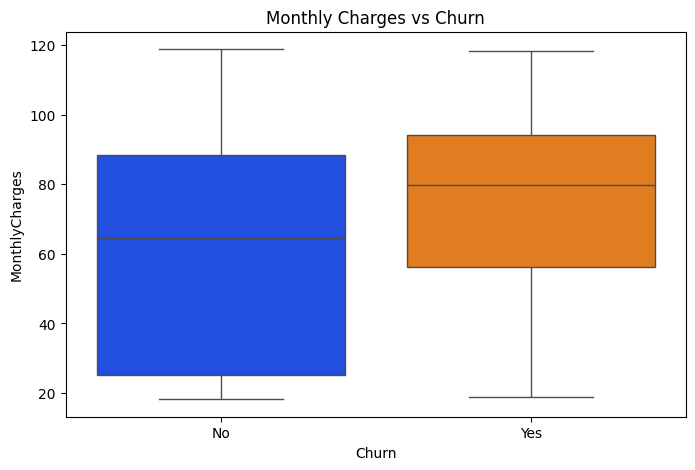

In [75]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn', palette='bright')

plt.title('Monthly Charges vs Churn')
plt.show()

#### Insight

- The boxplot shows that customers who churn tend to have higher monthly charges compared to those who do not churn, as indicated by the higher median.
- Both groups have a wide range of values, but the overall distribution suggests that higher monthly charges may be associated with increased churn.

## Tenure Distribution

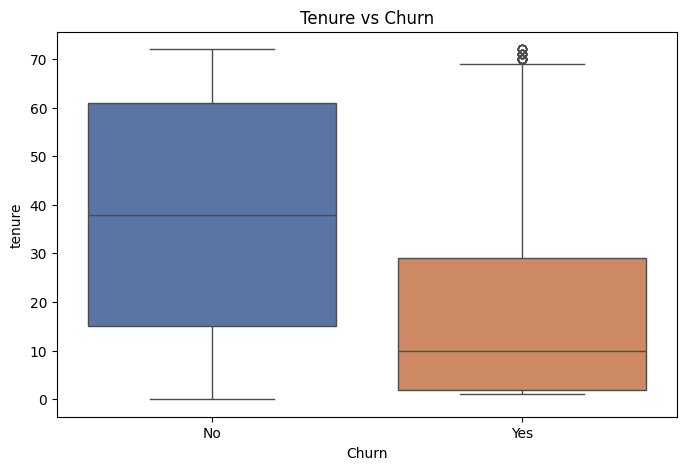

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df, hue='Churn' , palette='deep')

plt.title('Tenure vs Churn')
plt.show()

#### Insight

- The boxplot shows that customers who churn generally have lower tenure compared to those who stay.
- Customers who do not churn tend to have higher tenure, indicating long-term customers are less likely to leave.
- This suggests that newer customers are at a higher risk of churn.

## Internet Service vs Churn

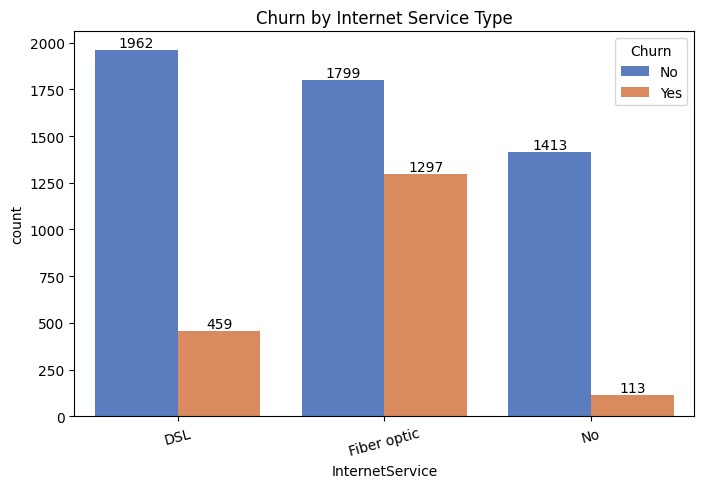

In [66]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='InternetService', hue='Churn', data=df, palette='muted')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn by Internet Service Type')
plt.xticks(rotation=15)

plt.show()

#### Insight

- The visualization shows that customers using fiber optic internet have a higher churn compared to other service types.
- Customers with DSL have relatively lower churn, while those with no internet service show very minimal churn.
- This suggests that customers using fiber optic services may be more likely to leave, possibly due to higher costs or service expectations.

## Payment Method vs Churn

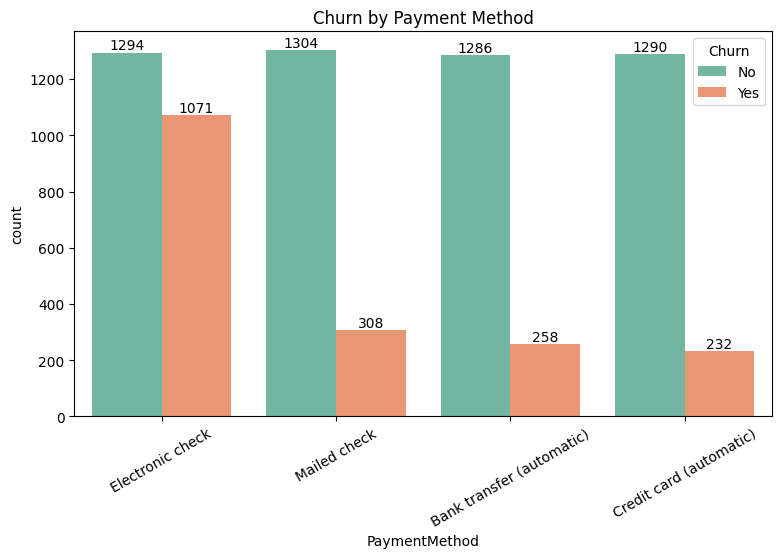

In [76]:
plt.figure(figsize=(9,5))

ax = sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set2')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn by Payment Method')
plt.xticks(rotation=30)

plt.show()

## Senior Citizen vs Churn

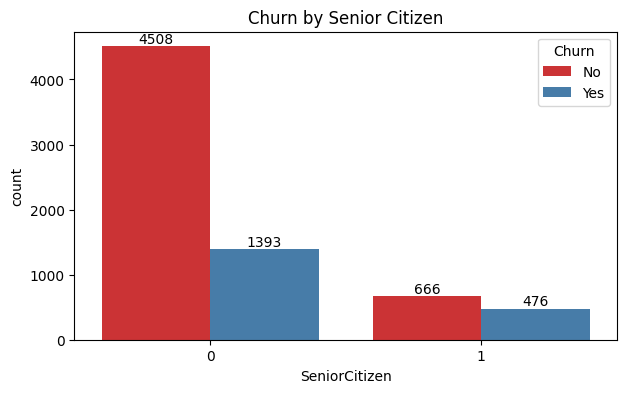

In [78]:
plt.figure(figsize=(7,4))

ax = sns.countplot(x='SeniorCitizen', hue='Churn', data=df, palette='Set1')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn by Senior Citizen')
plt.show()

#### Insight

The plot shows the churn distribution across senior and non-senior customers.

Senior citizens appear to have a slightly higher proportion of churn compared to non-senior customers, indicating age group may have some impact on customer retention.

## Gender vs Churn

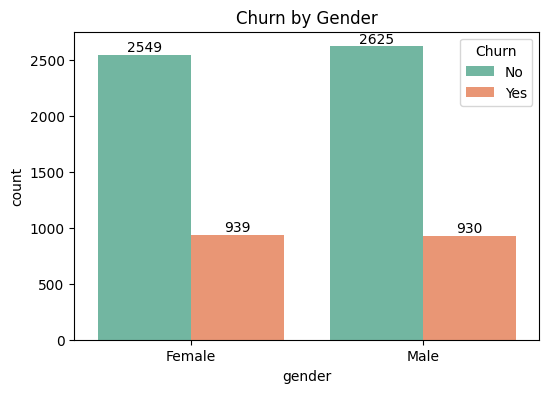

In [79]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='gender', hue='Churn', data=df, palette='Set2')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn by Gender')
plt.show()

#### Insight

The churn distribution between male and female customers appears to be similar.

This suggests that gender does not have a significant impact on customer churn in this dataset.

## Tech Support vs Churn

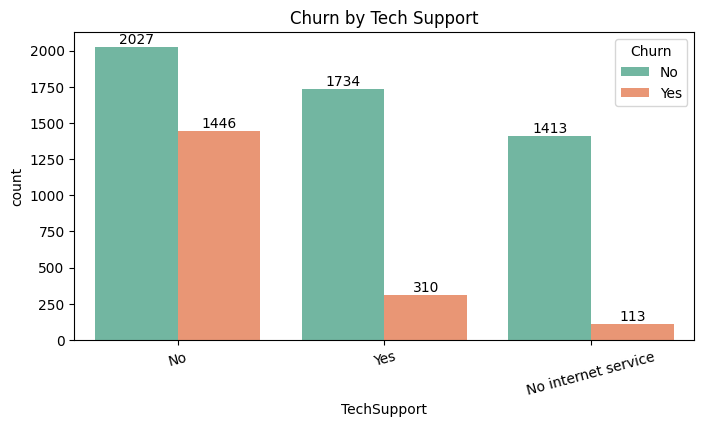

In [80]:
plt.figure(figsize=(8,4))

ax = sns.countplot(x='TechSupport', hue='Churn', data=df, palette='Set2')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn by Tech Support')
plt.xticks(rotation=15)
plt.show()

#### Insight

Customers who do not have tech support show a higher churn compared to those who have tech support.

This suggests that providing better support services may help reduce customer churn.

## Exploratory Data Analysis Summary

During the eda, we examined the dataset to understand its structure, patterns, and potential issues.

We started by reviewing the dataset shape, column names, and basic statistical summary to understand the distribution of numerical features. Initial checks confirmed that there were no explicit missing values in the dataset.

Further analysis of data types revealed that the `TotalCharges` column contains numerical values but is stored as an object type, indicating a data type inconsistency. This suggests the presence of hidden issues such as blank or improperly formatted values.

We also verified that there are no duplicate rows in the dataset, and unique identifiers such as `customerID` are correctly maintained.

Through visual analysis, several important patterns were identified:
- Customers with month-to-month contracts show higher churn.
- Customers with higher monthly charges are more likely to churn.
- Customers with lower tenure tend to churn more frequently.
- Fiber optic users and customers using electronic check show higher churn.
- Customers without tech support have increased churn risk.
- Gender does not show a significant impact on churn.

Overall, the dataset provides meaningful insights, but some preprocessing is required before modeling. The main issue identified is the incorrect data type of the `TotalCharges` column, which needs to be converted to numeric. Additionally, any hidden missing values resulting from this conversion will need to be handled in the data cleaning phase.